<a href="https://colab.research.google.com/github/lhiwi/FUTURE_DS_02/blob/main/Churn_patterns_%26_retention_drivers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

clean_path = "/content/drive/MyDrive/Future_DS/telco_cleaned_for_powerbi.csv"  # match your export folder
df = pd.read_csv(clean_path)

print("Shape:", df.shape)
df.head()

Shape: (7043, 24)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,SeniorCitizenFlag,HasInternet,HasPhone
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,No,Yes,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,No,Yes,Yes
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,No,Yes,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,No,Yes,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,No,Yes,Yes


# Overall churn rate(baseline KPI)

In [3]:
# 1) Convert churn to a numeric flag for easy rate calculations:
#    Yes -> 1 (churned), No -> 0 (retained)
df["ChurnFlag"] = np.where(df["Churn"] == "Yes", 1, 0)

# 2) Overall churn rate = average of the churn flag
overall_churn_rate = df["ChurnFlag"].mean()

# 3) Print both counts and the rate for stakeholder readability
churn_counts = df["Churn"].value_counts()
print("Churn counts:\n", churn_counts, "\n")
print("Overall churn rate:", round(overall_churn_rate * 100, 2), "%")

Churn counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64 

Overall churn rate: 26.54 %


## Churn rate by Contract (key retention driver)

In [4]:
# 1) Group by Contract and compute churn rate within each contract type
contract_churn = (
    df.groupby("Contract")["ChurnFlag"]
      .agg(churn_rate="mean", customers="count")
      .sort_values("churn_rate", ascending=False)
)

# 2) Convert churn rate to %
contract_churn["churn_rate_pct"] = (contract_churn["churn_rate"] * 100).round(2)

contract_churn

,churn_rate,customers,churn_rate_pct
Contract,,,
Month-to-month,0.427097,3875,42.71
One year,0.112695,1473,11.27
Two year,0.028319,1695,2.83


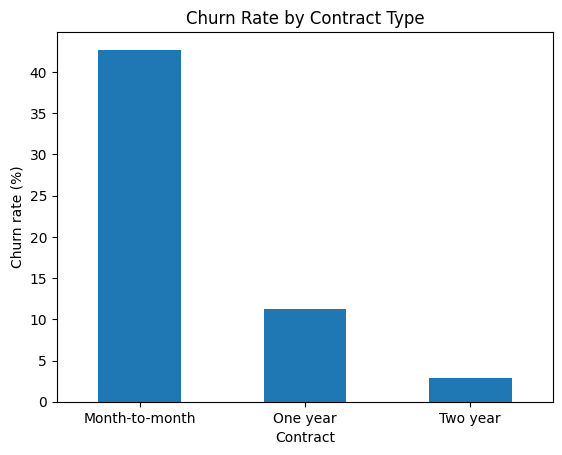

In [5]:
# Visualization: churn rate by contract

contract_churn["churn_rate_pct"].plot(kind="bar")
plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churn rate (%)")
plt.xticks(rotation=0)
plt.show()

### Churn rate by Payment Method (driver)

In [6]:
payment_churn = (
    df.groupby("PaymentMethod")["ChurnFlag"]
      .agg(churn_rate="mean", customers="count")
      .sort_values("churn_rate", ascending=False)
)

payment_churn["churn_rate_pct"] = (payment_churn["churn_rate"] * 100).round(2)

payment_churn

,churn_rate,customers,churn_rate_pct
PaymentMethod,,,
Electronic check,0.452854,2365,45.29
Mailed check,0.191067,1612,19.11
Bank transfer (automatic),0.167098,1544,16.71
Credit card (automatic),0.152431,1522,15.24


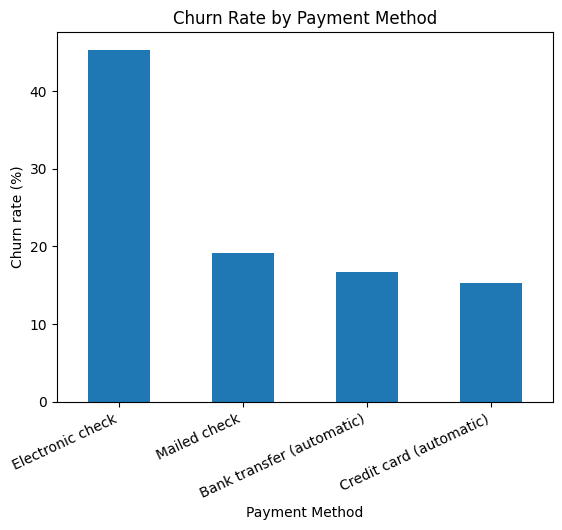

In [7]:
# Visualization: churn rate by payment method

payment_churn["churn_rate_pct"].plot(kind="bar")
plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn rate (%)")
plt.xticks(rotation=25, ha="right")
plt.show()

## Churn rate by Internet Service (driver)

In [8]:
internet_churn = (
    df.groupby("InternetService")["ChurnFlag"]
      .agg(churn_rate="mean", customers="count")
      .sort_values("churn_rate", ascending=False)
)

internet_churn["churn_rate_pct"] = (internet_churn["churn_rate"] * 100).round(2)

internet_churn

,churn_rate,customers,churn_rate_pct
InternetService,,,
Fiber optic,0.418928,3096,41.89
DSL,0.189591,2421,18.96
No,0.074050,1526,7.40


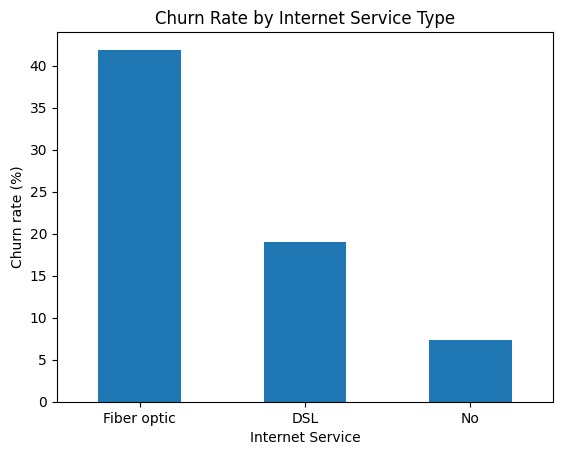

In [9]:
# Visualization: churn rate by internet service

internet_churn["churn_rate_pct"].plot(kind="bar")
plt.title("Churn Rate by Internet Service Type")
plt.xlabel("Internet Service")
plt.ylabel("Churn rate (%)")
plt.xticks(rotation=0)
plt.show()

## Interaction table (Contract x PaymentMethod)

In [10]:
# Goal: find the highest-risk combinations for targeted retention actions.

pivot_cp = pd.pivot_table(
    df,
    values="ChurnFlag",
    index="Contract",
    columns="PaymentMethod",
    aggfunc="mean"
)

# Convert to % for readability
pivot_cp_pct = (pivot_cp * 100).round(2)
pivot_cp_pct

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Contract,,,,
Month-to-month,34.13,32.78,53.73,31.58
One year,9.72,10.30,18.44,6.82
Two year,3.37,2.24,7.74,0.79


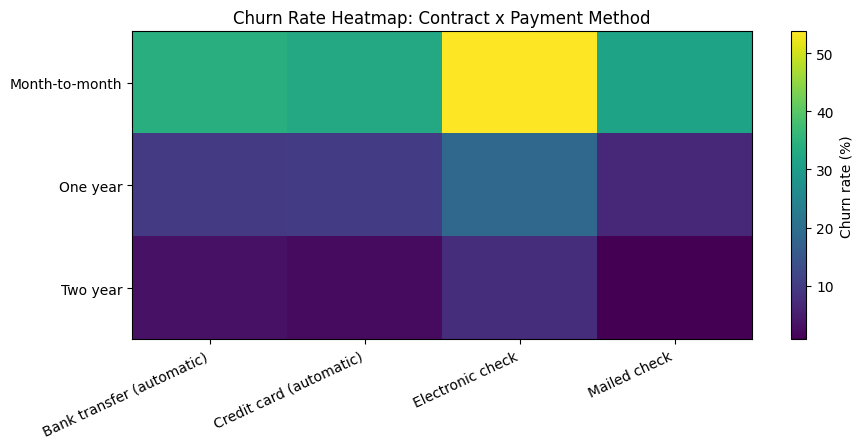

In [11]:
# Visualization: Heatmap of churn rate (%) for Contract x PaymentMethod

plt.figure(figsize=(10, 4))
plt.imshow(pivot_cp_pct.values, aspect="auto")
plt.xticks(range(len(pivot_cp_pct.columns)), pivot_cp_pct.columns, rotation=25, ha="right")
plt.yticks(range(len(pivot_cp_pct.index)), pivot_cp_pct.index)
plt.colorbar(label="Churn rate (%)")
plt.title("Churn Rate Heatmap: Contract x Payment Method")
plt.show()

## Interaction table (Contract x InternetService)

In [12]:
# Goal: identify which contract + internet type combinations are most at risk.

pivot_ci = pd.pivot_table(
    df,
    values="ChurnFlag",
    index="Contract",
    columns="InternetService",
    aggfunc="mean"
)

pivot_ci_pct = (pivot_ci * 100).round(2)
pivot_ci_pct

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,32.22,54.61,18.89
One year,9.30,19.29,2.47
Two year,1.91,7.23,0.78


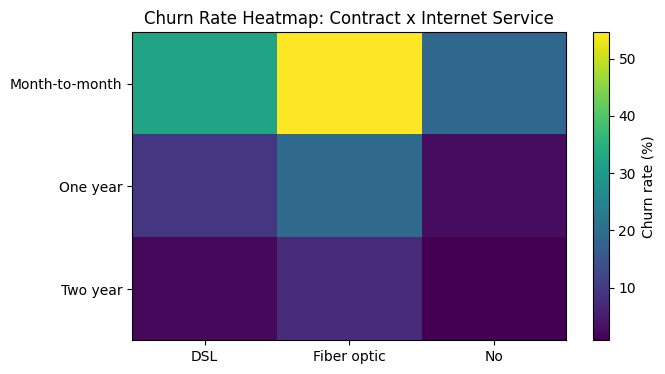

In [13]:
plt.figure(figsize=(7, 4))
plt.imshow(pivot_ci_pct.values, aspect="auto")
plt.xticks(range(len(pivot_ci_pct.columns)), pivot_ci_pct.columns, rotation=0)
plt.yticks(range(len(pivot_ci_pct.index)), pivot_ci_pct.index)
plt.colorbar(label="Churn rate (%)")
plt.title("Churn Rate Heatmap: Contract x Internet Service")
plt.show()

## Tenure distribution (retained vs churned)

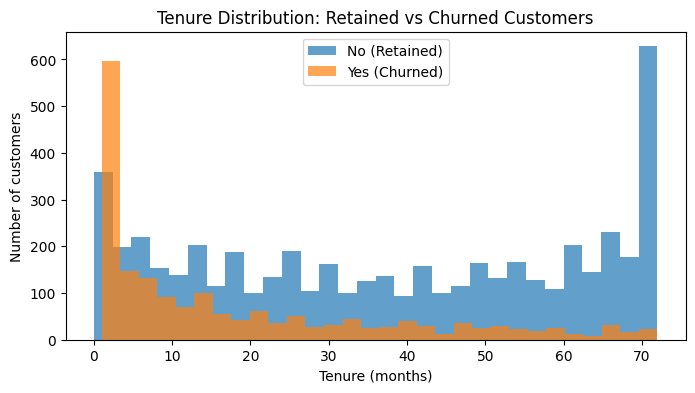

In [14]:
# Split tenure into two groups to compare churned vs retained customers
tenure_no = df.loc[df["Churn"] == "No", "tenure"]
tenure_yes = df.loc[df["Churn"] == "Yes", "tenure"]

plt.figure(figsize=(8,4))
plt.hist(tenure_no, bins=30, alpha=0.7, label="No (Retained)")
plt.hist(tenure_yes, bins=30, alpha=0.7, label="Yes (Churned)")
plt.title("Tenure Distribution: Retained vs Churned Customers")
plt.xlabel("Tenure (months)")
plt.ylabel("Number of customers")
plt.legend()
plt.show()

## Tenure groups (for cohort-style retention patterns)


In [15]:
bins = [-1, 6, 12, 24, 36, 72]
labels = ["0–6", "7–12", "13–24", "25–36", "37–72"]
df["TenureGroup"] = pd.cut(df["tenure"], bins=bins, labels=labels)

# Churn rate by tenure group
tenure_churn = (
    df.groupby("TenureGroup")["ChurnFlag"]
      .agg(churn_rate="mean", customers="count")
)

tenure_churn["churn_rate_pct"] = (tenure_churn["churn_rate"]*100).round(2)
tenure_churn

/tmp/ipykernel_9054/1264277703.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("TenureGroup")["ChurnFlag"]


,churn_rate,customers,churn_rate_pct
TenureGroup,,,
0–6,0.529372,1481,52.94
7–12,0.358865,705,35.89
13–24,0.287109,1024,28.71
25–36,0.216346,832,21.63
37–72,0.119294,3001,11.93


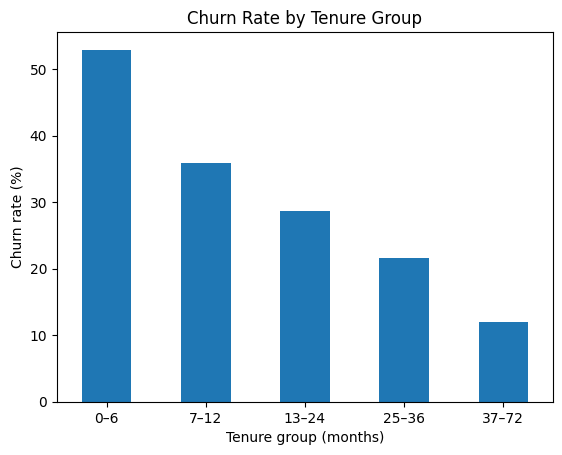

In [16]:
tenure_churn["churn_rate_pct"].plot(kind="bar")
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure group (months)")
plt.ylabel("Churn rate (%)")
plt.xticks(rotation=0)
plt.show()

In [17]:
#  Early-tenure (0–6 months) churn driver profiling

early = df[df["TenureGroup"] == "0–6"].copy()

print("Early-tenure customers:", early.shape[0])
print("Early-tenure churn rate (%):", round(early["ChurnFlag"].mean() * 100, 2))

Early-tenure customers: 1481
Early-tenure churn rate (%): 52.94


In [18]:
# Churn rate by Contract within early tenure
early_contract = early.groupby("Contract")["ChurnFlag"].agg(["mean", "count"]).sort_values("mean", ascending=False)
early_contract["churn_rate_pct"] = (early_contract["mean"]*100).round(2)
early_contract.rename(columns={"mean":"churn_rate","count":"customers"}, inplace=True)
early_contract

,churn_rate,customers,churn_rate_pct
Contract,,,
Month-to-month,0.552017,1413,55.20
One year,0.102564,39,10.26
Two year,0.000000,29,0.00


In [19]:
# Churn rate by PaymentMethod within early tenure
early_payment = early.groupby("PaymentMethod")["ChurnFlag"].agg(["mean", "count"]).sort_values("mean", ascending=False)
early_payment["churn_rate_pct"] = (early_payment["mean"]*100).round(2)
early_payment.rename(columns={"mean":"churn_rate","count":"customers"}, inplace=True)
early_payment

,churn_rate,customers,churn_rate_pct
PaymentMethod,,,
Electronic check,0.672012,686,67.20
Bank transfer (automatic),0.552632,114,55.26
Credit card (automatic),0.412214,131,41.22
Mailed check,0.374545,550,37.45


In [20]:
# Churn rate by InternetService within early tenure
early_internet = early.groupby("InternetService")["ChurnFlag"].agg(["mean", "count"]).sort_values("mean", ascending=False)
early_internet["churn_rate_pct"] = (early_internet["mean"]*100).round(2)
early_internet.rename(columns={"mean":"churn_rate","count":"customers"}, inplace=True)
early_internet

,churn_rate,customers,churn_rate_pct
InternetService,,,
Fiber optic,0.741935,620,74.19
DSL,0.482353,510,48.24
No,0.222222,351,22.22


### Contribution analysis (where churn volume comes from)

In [21]:
# Helper: churned customers only
churned = df[df["ChurnFlag"] == 1]

# 1) How many churned customers are month-to-month?
m2m_share = (churned["Contract"] == "Month-to-month").mean() * 100

# 2) How many churned customers use electronic check?
echeck_share = (churned["PaymentMethod"] == "Electronic check").mean() * 100

# 3) How many churned customers have fiber optic?
fiber_share = (churned["InternetService"] == "Fiber optic").mean() * 100

# 4) Combined: churned customers who are BOTH month-to-month AND electronic check
m2m_echeck_share = ((churned["Contract"] == "Month-to-month") &
                    (churned["PaymentMethod"] == "Electronic check")).mean() * 100

# 5) Combined: churned customers who are BOTH month-to-month AND fiber
m2m_fiber_share = ((churned["Contract"] == "Month-to-month") &
                   (churned["InternetService"] == "Fiber optic")).mean() * 100

print(f"Share of churned customers who are Month-to-month: {m2m_share:.2f}%")
print(f"Share of churned customers who use Electronic check: {echeck_share:.2f}%")
print(f"Share of churned customers who have Fiber optic: {fiber_share:.2f}%")
print(f"Share of churned customers who are Month-to-month + Electronic check: {m2m_echeck_share:.2f}%")
print(f"Share of churned customers who are Month-to-month + Fiber optic: {m2m_fiber_share:.2f}%")

Share of churned customers who are Month-to-month: 88.55%
Share of churned customers who use Electronic check: 57.30%
Share of churned customers who have Fiber optic: 69.40%
Share of churned customers who are Month-to-month + Electronic check: 53.18%
Share of churned customers who are Month-to-month + Fiber optic: 62.17%
